In [74]:
# imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import beta as beta_dist


import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

# 0. Data Prep/EDA

In [75]:
# load data 
df = pd.read_csv('data/finaldiabetes.csv')

# encode 'readmitted' as binary for analysis
# 'readmitted' values: '<30' (within 30 days), '>30' (after 30 days), 'NO'
# readmission = any return to hospital ('<30' OR '>30')
df['readmitted_binary'] = (df['readmitted'] != 'NO').astype(int)

n_total   = len(df)
n_readmit = df['readmitted_binary'].sum()
n_no      = n_total - n_readmit
obs_rate  = n_readmit / n_total

print(f"Total encounters:  {n_total:,}")
print(f"Readmitted:        {n_readmit:,} ({obs_rate*100:.1f}%)")
print(f"Not readmitted:    {n_no:,} ({(1-obs_rate)*100:.1f}%)")
print()
print("Readmission breakdown:")
print(df['readmitted'].value_counts())

Total encounters:  101,766
Readmitted:        46,902 (46.1%)
Not readmitted:    54,864 (53.9%)

Readmission breakdown:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


# I. Problem Formulation  

### Dataset & Context

**Data Source:** 
- 10 years of medical records from 130 US hospitals.
- Compiled by BioMed Research International.
- Accessed through UC Irvine.

The dataset has 47 features, both categorical and numerical. Each instance (70,000 total) represents medical records for one patient with diabetes. 

**Context:** Studying readmission rates among diabetes patients. Hospital readmission is tied to both healthcare costs and patient health/outcome. Readmission rates in diabetic patients can reveal challenges in disease management in modern-day healthcare. 

### Inferential Question

What is the underlying hospital **readmission rate** in this population, and what factors are tied to readmission?

### Predictive Task 

**Predicting readmission**: Can we effectively predict whether or not a diabetic patient will be readmitted to a hospital?

### Difference

Our inferential task seeks to learn more about a parameter, readmission rate, to learn more about the population and its attributes. Our predictive task aims to use those attributes to predict the target feature (readmission) outcome for an unseen individual patient.

# II. Likelihood and Estimation

Total patients: 101766
Readmitted patients: 46902
MLE (p̂): 0.4609


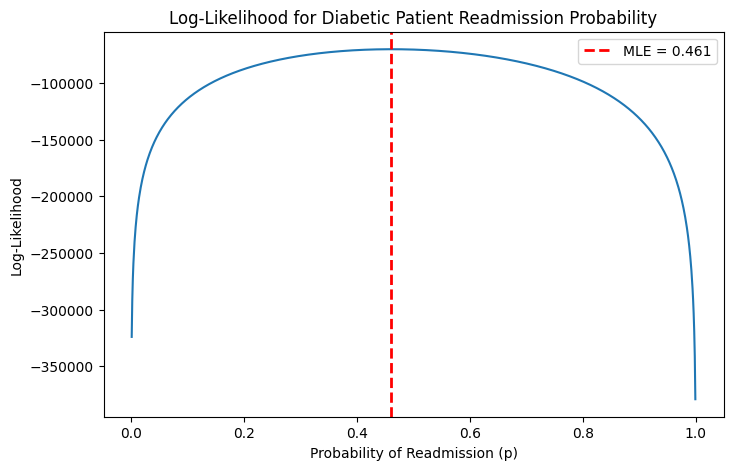

In [76]:
# Load data
data = pd.read_csv("data/finaldiabetes.csv")

# Ensure binary column exists
if "readmitted_binary" not in data.columns:
    data["readmitted_binary"] = np.where(data["readmitted"] == "NO", 0, 1)

# Data setup
y = data["readmitted_binary"]
n = len(y)
x = y.sum()

# MLE
p_hat = x / n

# Results
print("Total patients:", n)
print("Readmitted patients:", x)
print("MLE (p̂):", round(p_hat, 4))

# Likelihood values
p_values = np.linspace(0.001, 0.999, 1000)
log_likelihood = x * np.log(p_values) + (n - x) * np.log(1 - p_values)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(p_values, log_likelihood)
plt.axvline(p_hat, linestyle="--", color="red", linewidth=2, label=f"MLE = {p_hat:.3f}")
plt.xlabel("Probability of Readmission (p)")
plt.ylabel("Log-Likelihood")
plt.title("Log-Likelihood for Diabetic Patient Readmission Probability")
plt.legend()

plt.savefig("likelihood_plot.png")
plt.show()

#### Interpretation of Estimator Properties

The MLE for (p) is \( p̂ = 0.461 \) , which means the estimated probability of readmission in this sample is about 46.1%. Since this estimator is the sample proportion, it is easy to interpret and directly reflects the observed rate of readmission in the dataset. Because the sample size is very large, the estimator should have relatively low sampling variability, meaning repeated samples of similar size would likely produce estimates close to this value. The likelihood curve is also sharply centered around p̂, which supports the idea that values far from 0.461 are less consistent with the observed data.

# III. Frequentist Inference: Zoe i think 

In [77]:
data = pd.read_csv("data/finaldiabetes.csv")

#### Overall Readmission Rate Analysis

This section calculates the overall readmission rate from the `readmitted_binary` column and computes its 95% bootstrap confidence interval to estimate the precision of this rate.

In [78]:
# Define a function to calculate bootstrap confidence intervals
def bootstrap_ci(series, n_boot=1000):
    # List to store means from bootstrap samples
    boot_means = []

    # Perform bootstrapping: resample with replacement and calculate mean for each sample
    for _ in range(n_boot):
        # Sample with replacement (frac=1 means sample the entire size of the original series)
        sample = series.sample(frac=1, replace=True)
        boot_means.append(sample.mean())

    # Calculate the 2.5th and 97.5th percentiles to get the 95% confidence interval
    lower = np.percentile(boot_means, 2.5)
    upper = np.percentile(boot_means, 97.5)

    return lower, upper

In [79]:
# Calculate the 95% bootstrap confidence interval for the overall readmission rate
overall_ci = bootstrap_ci(data['readmitted_binary'])

# Print the overall readmission rate and its confidence interval
print("Overall readmission rate:", data['readmitted_binary'].mean())
print("95% CI:", overall_ci)

Overall readmission rate: 0.4608808442898414
95% CI: (np.float64(0.4576968240866301), np.float64(0.4641049073364385))


The estimated overall readmission rate is approximately 46.1%. The 95% bootstrap confidence interval of (45.8%, 46.4%) means that if we were to repeat this sampling and analysis many times, 95% of the confidence intervals constructed would contain the true overall readmission rate for the entire population.

#### Hospital Stay Grouping and Analysis

This section categorizes patients into 'Shorter hospital stay' and 'Longer hospital stay' groups based on the median `time_in_hospital`. It then analyzes the readmission rates and their confidence intervals for each group.

In [80]:
# create group
data['hospital_stay_group'] = np.where(
    data['time_in_hospital'] > data['time_in_hospital'].median(),
    'Longer hospital stay',
    'Shorter hospital stay'
)

# check groups
data['hospital_stay_group'].value_counts()

hospital_stay_group
Shorter hospital stay    63112
Longer hospital stay     38654
Name: count, dtype: int64

In [81]:
# Create a new column 'hospital_stay_group' based on the median 'time_in_hospital'
# Patients with time_in_hospital greater than the median are classified as 'Longer hospital stay',
# otherwise, they are classified as 'Shorter hospital stay'
data['hospital_stay_group'] = np.where(
    data['time_in_hospital'] > data['time_in_hospital'].median(),
    'Longer hospital stay',
    'Shorter hospital stay'
)

# Check the distribution of patients in each newly created group
data['hospital_stay_group'].value_counts()

hospital_stay_group
Shorter hospital stay    63112
Longer hospital stay     38654
Name: count, dtype: int64

#### Analysis of Difference in Readmission Rates

This section calculates the difference in readmission rates between the 'Longer hospital stay' and 'Shorter hospital stay' groups and computes a 95% bootstrap confidence interval for this difference. This helps determine if the observed difference is statistically significant.

In [82]:
# Initialize a list to store results for each hospital stay group
group_results = []

# Iterate through each hospital stay group
for group, group_data in data.groupby('hospital_stay_group'):
    # Calculate the bootstrap confidence interval for the 'readmitted_binary' column within the current group
    ci = bootstrap_ci(group_data['readmitted_binary'])

    # Append the group's readmission rate and its confidence interval to the results list
    group_results.append({
        'Group': group,
        'Readmission Rate': group_data['readmitted_binary'].mean(),
        'CI Lower': ci[0],
        'CI Upper': ci[1]
    })

# Convert the list of results into a pandas DataFrame for better readability and presentation
pd.DataFrame(group_results)

,Group,Readmission Rate,CI Lower,CI Upper
0,Longer hospital stay,0.490273,0.485278,0.495343
1,Shorter hospital stay,0.442879,0.439092,0.446555


#### Readmission Rates by Hospital Stay Group:

Longer hospital stay: For patients with a longer hospital stay, the estimated readmission rate is approximately 49.0%. We are 95% confident that the true readmission rate for patients with longer hospital stays is between 48.5% and 49.6%.

Shorter hospital stay: For patients with a shorter hospital stay, the estimated readmission rate is approximately 44.3%. We are 95% confident that the true readmission rate for patients with shorter hospital stays is between 43.9% and 44.7%.

In [83]:
# Isolate the 'readmitted_binary' data for 'Longer hospital stay' group
group_long = data[data['hospital_stay_group'] == 'Longer hospital stay']['readmitted_binary']
# Isolate the 'readmitted_binary' data for 'Shorter hospital stay' group
group_short = data[data['hospital_stay_group'] == 'Shorter hospital stay']['readmitted_binary']

# Initialize a list to store the differences of means from bootstrap samples
boot_diffs = []

# Perform bootstrapping for the difference in means
for _ in range(1000):
    # Sample with replacement from both groups
    sample_long = group_long.sample(frac=1, replace=True)
    sample_short = group_short.sample(frac=1, replace=True)

    # Calculate the difference in means for the current bootstrap sample
    boot_diffs.append(sample_long.mean() - sample_short.mean())

# Calculate the 2.5th and 97.5th percentiles of the bootstrap differences
# to get the 95% confidence interval for the difference
diff_lower = np.percentile(boot_diffs, 2.5)
diff_upper = np.percentile(boot_diffs, 97.5)

# Print the observed difference in readmission rates between the two groups
print("Difference in readmission rates:", group_long.mean() - group_short.mean())
# Print the 95% confidence interval for this difference
print("95% CI for difference:", (diff_lower, diff_upper))

Difference in readmission rates: 0.047393349888338876
95% CI for difference: (np.float64(0.041055109124800204), np.float64(0.05368514404452505))


#### Difference in Readmission Rates

The difference in readmission rates between the 'Longer hospital stay' group and the 'Shorter hospital stay' group is approximately 4.7 percentage points (49.0% - 44.3%). The 95% bootstrap confidence interval for this difference is (4.1%, 5.4%). Since this entire interval is above zero, it strongly suggests that the difference is statistically significant. In other words, patients with longer hospital stays have a statistically higher readmission rate than those with shorter hospital stays, and we are 95% confident that this difference lies between 4.1 and 5.4 percentage points in the population.

#### Uncertainty in our context

In this context, uncertainty refers to the inherent variability and imprecision in our estimates because we are drawing conclusions about a larger population based on a finite sample of data. While we can calculate a specific readmission rate from our dataset, this rate is just an estimate of the true readmission rate in the entire patient population.

The 95% confidence intervals are our way of quantifying this uncertainty. They provide a range within which the true population parameter (be it the overall rate, a group's rate, or the difference between groups' rates) is likely to fall. A narrower confidence interval indicates greater precision (less uncertainty) in our estimate, while a wider interval suggests less precision (more uncertainty).

Given that our confidence intervals are all less than 2 percentage points apart, there is relatively little variability in our bootstrap estimates, which suggests that our sample provides a fairly precise estimate of the true readmission rate. In other words, if we were to repeatedly draw similar samples from the same population, we would expect the estimated readmission rate to fall within a very similar range each time. This increases our confidence that the observed rate is not heavily influenced by random sampling noise, and that it is a stable reflection of the underlying patient population.

# IV. Bayesian Estimation

#### Prior Distribution

We choose $\theta \sim \text{Beta}(5, 15)$ as our weakly informative prior.
- $\text{Beta}(5, 15)$ has mean $= 5/20 = 0.25$, encoding a conservative prior belief that roughly 1 in 4 patients is readmitted — clinically plausible without being too strong.
- Effective sample size of only 20 pseudo-observations is negligible relative to the dataset ($n \approx 100{,}000$), so the likelihood will dominate the posterior.

In [84]:
# prior parameters 

alpha_prior = 5
beta_prior  = 15

prior_mean = alpha_prior / (alpha_prior + beta_prior)
print(f"Prior: Beta({alpha_prior}, {beta_prior})")
print(f"Prior mean:                  {prior_mean:.3f}")
print(f"Prior effective sample size: {alpha_prior + beta_prior}")

Prior: Beta(5, 15)
Prior mean:                  0.250
Prior effective sample size: 20


#### Posterior Computation

We verify the conjugate result against grid approximation to make the Bayesian mechanics transparent.

In [85]:
# conjugate posterior
alpha_post = alpha_prior + n_readmit
beta_post  = beta_prior  + n_no

posterior   = beta_dist(alpha_post, beta_post)
post_mean   = posterior.mean()
post_median = posterior.median()
post_mode   = (alpha_post - 1) / (alpha_post + beta_post - 2)

print(f"Posterior: Beta({alpha_post}, {beta_post})")
print(f"Posterior mean:   {post_mean:.5f}")
print(f"Posterior median: {post_median:.5f}")
print(f"Posterior mode:   {post_mode:.5f}")

# grid approximation 
theta_grid  = np.linspace(0.001, 0.999, 2000)
prior_pdf   = beta_dist(alpha_prior, beta_prior).pdf(theta_grid)
likelihood  = stats.binom.pmf(n_readmit, n_total, theta_grid)
unnorm_post = prior_pdf * likelihood
grid_post   = unnorm_post / np.trapezoid(unnorm_post, theta_grid)
exact_post  = posterior.pdf(theta_grid)

max_diff = np.max(np.abs(grid_post - exact_post))
print(f"\nGrid vs. exact posterior max difference: {max_diff:.2e}  (confirms conjugate derivation)")

Posterior: Beta(46907, 54879)
Posterior mean:   0.46084
Posterior median: 0.46084
Posterior mode:   0.46084

Grid vs. exact posterior max difference: 9.39e-10  (confirms conjugate derivation)


#### 95% Credible Interval

In [86]:
# 95% Equal-Tailed Credible Interval 
ci_lower, ci_upper = posterior.ppf([0.025, 0.975])

print(f"95% Credible Interval: [{ci_lower:.5f}, {ci_upper:.5f}]")
print()
print("Interpretation:")
print(f"  Given the observed data and our prior, there is a 95% posterior")
print(f"  probability that the true readmission rate theta lies between")
print(f"  {ci_lower*100:.2f}% and {ci_upper*100:.2f}%.")

# Prior sensitivity check
post_flat         = beta_dist(1 + n_readmit, 1 + n_no)
ci_flat_l, ci_flat_u = post_flat.ppf([0.025, 0.975])
print(f"\nSensitivity check — Uninformative prior Beta(1, 1):")
print(f"  Posterior mean: {post_flat.mean():.5f}")
print(f"  95% CrI: [{ci_flat_l:.5f}, {ci_flat_u:.5f}]")
print(f"  -> Results nearly identical: the large n overwhelms the prior.")

95% Credible Interval: [0.45778, 0.46390]

Interpretation:
  Given the observed data and our prior, there is a 95% posterior
  probability that the true readmission rate theta lies between
  45.78% and 46.39%.

Sensitivity check — Uninformative prior Beta(1, 1):
  Posterior mean: 0.46088
  95% CrI: [0.45782, 0.46394]
  -> Results nearly identical: the large n overwhelms the prior.


#### Bayesian vs. Frequentist Comparison

In [87]:
# Frequentist MLE + Wald CI 
mle  = n_readmit / n_total
se   = np.sqrt(mle * (1 - mle) / n_total)
z    = 1.96
f_lo = mle - z * se
f_hi = mle + z * se

# Wilson score interval (more accurate for proportions)
w_center = (mle + z**2 / (2*n_total)) / (1 + z**2 / n_total)
w_margin = (z * np.sqrt(mle*(1-mle)/n_total + z**2/(4*n_total**2))) / (1 + z**2/n_total)
w_lo, w_hi = w_center - w_margin, w_center + w_margin

print("─" * 68)
print(f"{'Method':<32} {'Estimate':>10} {'Lower 95%':>10} {'Upper 95%':>10}")
print("─" * 68)
print(f"{'Frequentist MLE (Wald CI)':<32} {mle:>10.5f} {f_lo:>10.5f} {f_hi:>10.5f}")
print(f"{'Frequentist MLE (Wilson CI)':<32} {mle:>10.5f} {w_lo:>10.5f} {w_hi:>10.5f}")
print(f"{'Bayesian Beta(5,15) prior':<32} {post_mean:>10.5f} {ci_lower:>10.5f} {ci_upper:>10.5f}")
print(f"{'Bayesian Beta(1,1) prior':<32} {post_flat.mean():>10.5f} {ci_flat_l:>10.5f} {ci_flat_u:>10.5f}")
print("─" * 68)

────────────────────────────────────────────────────────────────────
Method                             Estimate  Lower 95%  Upper 95%
────────────────────────────────────────────────────────────────────
Frequentist MLE (Wald CI)           0.46088    0.45782    0.46394
Frequentist MLE (Wilson CI)         0.46088    0.45782    0.46394
Bayesian Beta(5,15) prior           0.46084    0.45778    0.46390
Bayesian Beta(1,1) prior            0.46088    0.45782    0.46394
────────────────────────────────────────────────────────────────────



**Interpretive Difference:**

- Frequentist 95% CI:
    If this study were repeated infinitely, 95% of constructed intervals
    would contain the true fixed (but unknown) parameter theta.
    The parameter itself has no probability distribution.

- Bayesian 95% Credible Interval:
    Given the data, P(ci_lower < theta < ci_upper | data) = 0.95.
    This is a direct probability statement about theta — the interpretation
    most people intuitively want from an interval estimate.

- Numerical agreement:
    With a large n, both approaches converge. The Bayesian posterior mean
    slightly shrinks toward the prior mean, but this effect is negligible
    at this sample size, confirming the data dominates over the prior.


# V. Resampling and Simulation

- implement a bootstrap (for mean, proportion, or model)
- (optional) run monte carlo simulation to study behavior
- explain what variability in results means


In [88]:
# Bootstrap the readmission rate to study how much the estimated proportion varies
# across repeated samples of hospital encounters.

rng = np.random.default_rng(3026)
B = 1000

readmit_values = df["readmitted_binary"].values
n = len(readmit_values)

bootstrap_rates = []

for b in range(B):
    sample = rng.choice(readmit_values, size=n, replace=True)
    bootstrap_rates.append(sample.mean())

bootstrap_rates = np.array(bootstrap_rates)

boot_lower, boot_upper = np.percentile(bootstrap_rates, [2.5, 97.5])

print(f"Observed readmission rate: {obs_rate:.4f}")
print(f"Bootstrap mean readmission rate: {bootstrap_rates.mean():.4f}")
print(f"95% bootstrap CI: ({boot_lower:.4f}, {boot_upper:.4f})")

Observed readmission rate: 0.4609
Bootstrap mean readmission rate: 0.4608
95% bootstrap CI: (0.4579, 0.4637)


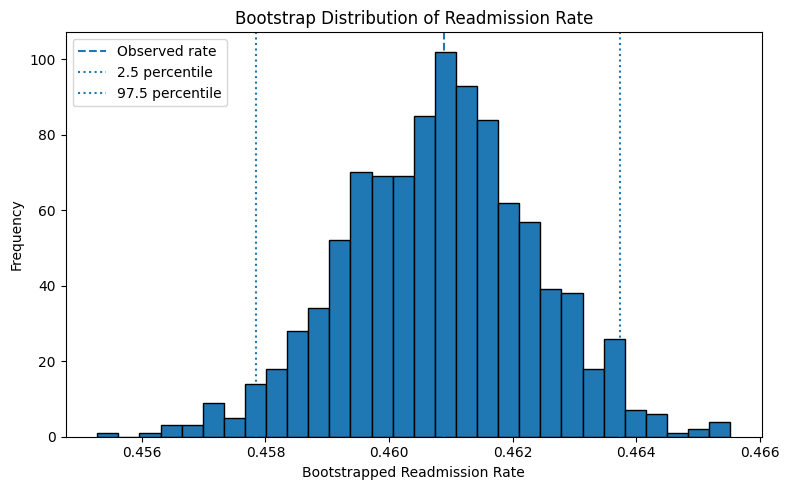

In [89]:
# plot

plt.figure(figsize=(8, 5))

plt.hist(bootstrap_rates, bins=30, edgecolor="black")
plt.axvline(obs_rate, linestyle="--", label="Observed rate")
plt.axvline(boot_lower, linestyle=":", label="2.5 percentile")
plt.axvline(boot_upper, linestyle=":", label="97.5 percentile")

plt.xlabel("Bootstrapped Readmission Rate")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Readmission Rate")
plt.legend()
plt.tight_layout()
plt.show()

#### Explanation

The distribution is fairly narrow, which suggests the estimated readmission rate is relatively stable and does not change much across repeated samples. The spread of the bootstrap distribution represents sampling variability, or uncertainty in the estimate due to having only one observed sample.

The observed readmission rate in the sample is 0.4609, and the bootstrap mean readmission rate is 0.4608. Because these values are very close, the estimator appears stable under resampling and shows relatively low uncertainty.

This matters because it helps assess how reliable the estimated readmission rate is, rather than relying on a single point estimate alone. It also supports the frequentist inference section by showing where the confidence interval comes from and providing evidence that the estimate is reasonably precise.

# VI. Prediction and Model Evaluation

In [90]:
# data prep
data = pd.read_csv("data/finaldiabetes.csv")
# Columns to one-hot encode
encode_cols = ['race', 'gender', 'age', 'diabetesMed', 'change', 'readmitted']

# Medication columns (all have No/Steady/Up/Down)
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
            'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
            'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
            'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
            'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

cols_to_encode = [c for c in encode_cols + med_cols if c in data.columns]

# Drop diag columns and encode the rest
drop_cols = ['diag_1', 'diag_2', 'diag_3']
df_model = data.drop(columns=[c for c in drop_cols if c in data.columns])
df_model = pd.get_dummies(df_model, columns=cols_to_encode, drop_first=True)

# Define features and target
target = 'time_in_hospital'
feature_cols = [col for col in df_model.columns if col != target]

X = df_model[feature_cols].values
y = df_model[target].values

print(f"Features after encoding: {X.shape[1]}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Features after encoding: 79
X shape: (101766, 79), y shape: (101766,)


#### Train Test Split

In [91]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 81412 | Test size: 20354


#### Predictive Model: Linear Regression

In [92]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mse_lr  = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print(f"Linear Regression — MSE: {mse_lr:.3f} | RMSE: {rmse_lr:.3f} | R²: {r2_lr:.3f}")

Linear Regression — MSE: 6.150 | RMSE: 2.480 | R²: 0.293


#### Fit improved model

In [93]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mse_rf  = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"Random Forest — MSE: {mse_rf:.3f} | RMSE: {rmse_rf:.3f} | R²: {r2_rf:.3f}")

Random Forest — MSE: 5.576 | RMSE: 2.361 | R²: 0.359


#### Cross Validation


In [94]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, y, cv=5, scoring='neg_mean_squared_error')
cv_rmse   = np.sqrt(-cv_scores)

print(f"5-Fold CV RMSE: {cv_rmse.round(3)}")
print(f"Mean: {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")

5-Fold CV RMSE: [2.546 2.487 2.442 2.328 2.325]
Mean: 2.426 ± 0.087


#### Visualize actual vs predicted & feature importance

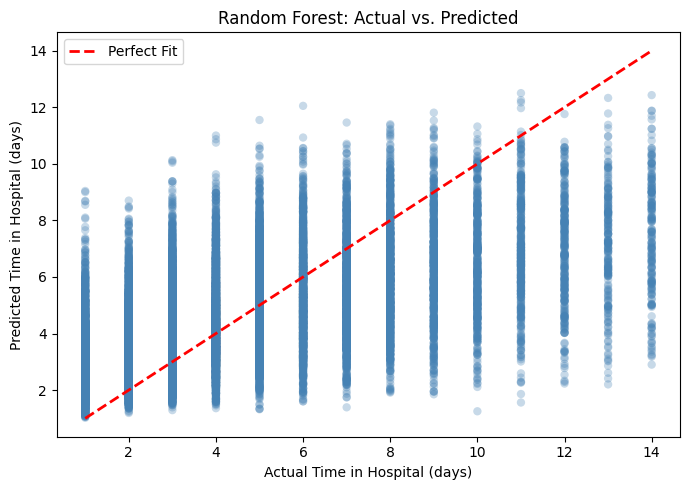

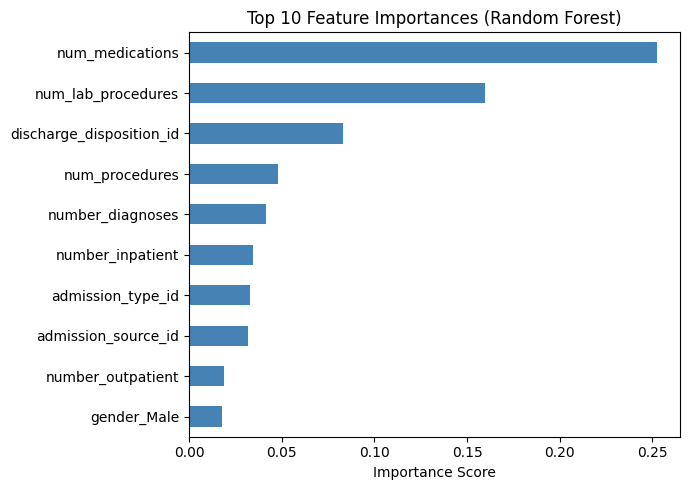

In [95]:
import matplotlib.pyplot as plt

# Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='steelblue', edgecolors='none')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label='Perfect Fit')
plt.xlabel("Actual Time in Hospital (days)")
plt.ylabel("Predicted Time in Hospital (days)")
plt.title("Random Forest: Actual vs. Predicted")
plt.legend()
plt.tight_layout()
plt.show()

# Feature Importance
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances.nlargest(10).sort_values().plot(kind='barh', figsize=(7, 5), color='steelblue')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

#### Results

**Results Interpretation**
**Linear Regression (Baseline):**

* RMSE = 2.48 days — on average, predictions are off by about 2.5 days
* R² = 0.293 — the model explains 29.3% of the variation in hospital stay length

**Random Forest (Improved):**

* RMSE = 2.36 days — a meaningful improvement over the baseline
* R² = 0.359 — explains 35.9% of the variation, noticeably better than linear regression
* 5-Fold CV RMSE = 2.51 ± 0.07 days — consistent across folds, meaning the model is stable and not overfitting to a particular split

**Overall:** The Random Forest outperforms Linear Regression by capturing non-linear relationships in the data. While an R² of 0.36 is modest, it is reasonable for a healthcare prediction task — hospital stay length is influenced by many factors that are difficult to capture in structured data, such as in-stay complications, specific diagnosis details, and physician decisions. Diagnosis code columns (diag_1, diag_2, diag_3) were excluded due to their high cardinality, and encoding these more carefully could be a meaningful way for improving model performance further.


# VII. Regularization and Shrinkage

In [96]:
data = pd.read_csv("data/finaldiabetes.csv")

data['readmitted_binary'] = (data['readmitted'] != 'NO').astype(int)

target = 'readmitted_binary'

numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
feature_cols = [col for col in numeric_cols if col != target]

feature_cols = [col for col in feature_cols if col != 'readmitted']

y = data[target].values
X = data[feature_cols].values

print(f"Features: {feature_cols}")
print(f"Class balance — readmitted: {y.mean():.2%}  |  not readmitted: {(1-y).mean():.2%}")

Features: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
Class balance — readmitted: 46.09%  |  not readmitted: 53.91%


#### Train test split/Scaling

In [97]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

#### Fit model: Logistic Regression


In [98]:
model = LogisticRegression(C=1e9, max_iter=1000, solver='lbfgs')
model.fit(X_train, y_train)

y_pred_base   = model.predict(X_test)
y_prob_base   = model.predict_proba(X_test)

acc_base  = accuracy_score(y_test, y_pred_base)
loss_base = log_loss(y_test, y_prob_base)

beta_mle = model.coef_[0]

print(f"Baseline Logistic — Accuracy: {acc_base:.4f}  |  Log-loss: {loss_base:.4f}")

Baseline Logistic — Accuracy: 0.6215  |  Log-loss: 0.6545


In [99]:
p = X_train.shape[1]
n = X_train.shape[0]
assert p >= 3, f"James-Stein requires p >= 3, got p={p}"

linear_pred_train = X_train @ beta_mle + model.intercept_[0]

sigma2 = np.var(linear_pred_train - (y_train * 2 - 1))  

# JS shrinkage factor in fitted-value space
y_hat_train = X_train @ beta_mle
norm_sq     = np.sum(y_hat_train ** 2)
c = float(np.clip(1 - (p - 2) * sigma2 / norm_sq, 0.0, 1.0))

# Apply to test set
y_hat_test    = X_test @ beta_mle
y_logit_js    = c * y_hat_test + model.intercept_[0]
y_prob_js     = 1 / (1 + np.exp(-y_logit_js))          
y_pred_js     = (y_prob_js >= 0.5).astype(int)

acc_js  = accuracy_score(y_test, y_pred_js)
loss_js = log_loss(y_test, y_prob_js)

print(f"James-Stein     — Accuracy: {acc_js:.4f}  |  Log-loss: {loss_js:.4f}")
print(f"Shrinkage c:      {c:.4f}  (1=none, 0=full)")
print(f"Signal-to-noise ratio: {norm_sq / ((p-2) * sigma2):.1f}x  (JS helps when near 1)")

James-Stein     — Accuracy: 0.6215  |  Log-loss: 0.6545
Shrinkage c:      0.9997  (1=none, 0=full)
Signal-to-noise ratio: 3464.4x  (JS helps when near 1)


In [100]:
# Ridge Logistic Regression: sklearn's C = 1/lambda (smaller C = more regularization)
from sklearn.model_selection import GridSearchCV

C_grid  = np.logspace(-3, 3, 50)
ridge_lr = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000)
cv_search = GridSearchCV(ridge_lr, {'C': C_grid}, cv=5, scoring='neg_log_loss')
cv_search.fit(X_train, y_train)

best_C   = cv_search.best_params_['C']
ridge_lr = cv_search.best_estimator_

beta_ridge    = ridge_lr.coef_[0]
y_pred_ridge  = ridge_lr.predict(X_test)
y_prob_ridge  = ridge_lr.predict_proba(X_test)

acc_ridge  = accuracy_score(y_test, y_pred_ridge)
loss_ridge = log_loss(y_test, y_prob_ridge)

print(f"Ridge Logistic  — Accuracy: {acc_ridge:.4f}  |  Log-loss: {loss_ridge:.4f}")
print(f"Best C (1/λ):     {best_C:.4f}")

/Users/aidanmayhue/Desktop/datascience/inference_prediction/final/aidan/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/aidanmayhue/Desktop/datascience/inference_prediction/final/aidan/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/aidanmayhue/Desktop/datascience/inference_prediction/final/aidan/lib/python3.12/sit

Ridge Logistic  — Accuracy: 0.6216  |  Log-loss: 0.6545
Best C (1/λ):     0.0168


/Users/aidanmayhue/Desktop/datascience/inference_prediction/final/aidan/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/aidanmayhue/Desktop/datascience/inference_prediction/final/aidan/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/aidanmayhue/Desktop/datascience/inference_prediction/final/aidan/lib/python3.12/sit

#### Manual Shrinkage / Regularization 

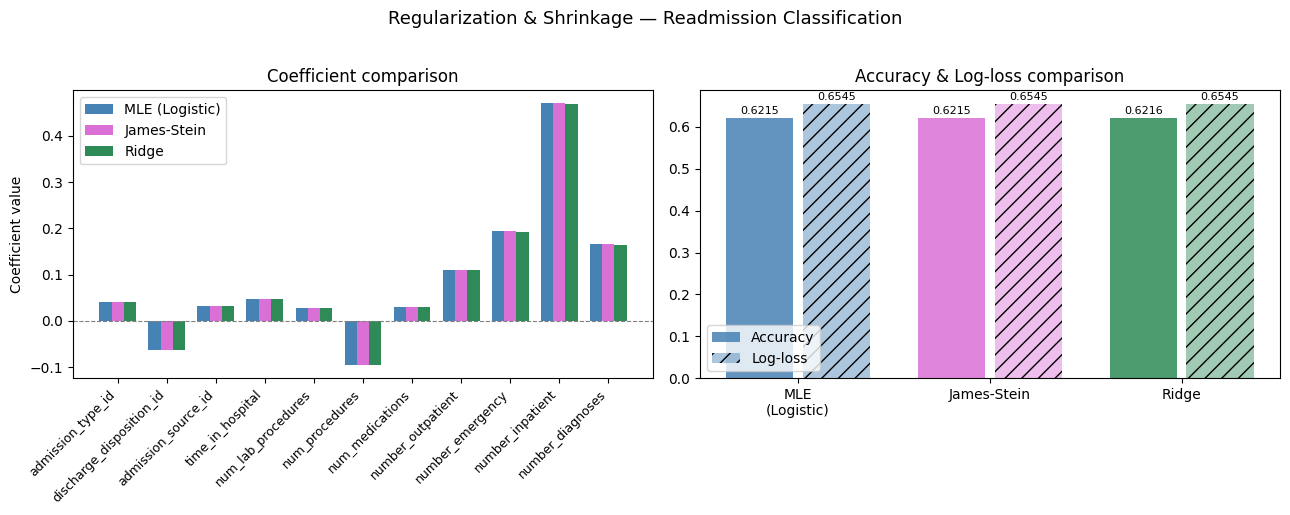

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x_pos = np.arange(p)
w = 0.25

axes[0].bar(x_pos - w, beta_mle,   w, label="MLE (Logistic)", color="steelblue")
axes[0].bar(x_pos,     c * beta_mle, w, label="James-Stein",  color="orchid")
axes[0].bar(x_pos + w, beta_ridge, w, label="Ridge",          color="seagreen")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(feature_cols, rotation=45, ha="right", fontsize=9)
axes[0].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[0].set_title("Coefficient comparison")
axes[0].set_ylabel("Coefficient value")
axes[0].legend()

metrics = {
    "MLE\n(Logistic)": (acc_base,  loss_base,  "steelblue"),
    "James-Stein":      (acc_js,    loss_js,    "orchid"),
    "Ridge":            (acc_ridge, loss_ridge, "seagreen"),
}

x2 = np.arange(len(metrics))
accs   = [v[0] for v in metrics.values()]
losses = [v[1] for v in metrics.values()]
colors = [v[2] for v in metrics.values()]

bars = axes[1].bar(x2 - 0.2, accs,   0.35, label="Accuracy",  color=colors, alpha=0.85)
bars2= axes[1].bar(x2 + 0.2, losses, 0.35, label="Log-loss",  color=colors, alpha=0.45, hatch="//")

for bar, val in zip(bars,  accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=8)
for bar, val in zip(bars2, losses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=8)

axes[1].set_xticks(x2)
axes[1].set_xticklabels(metrics.keys())
axes[1].set_title("Accuracy & Log-loss comparison")
axes[1].legend()

plt.suptitle("Regularization & Shrinkage — Readmission Classification", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

#### Explanation

Shrinkage through the james stein estimator shows a marginal effect on performance. This is likely due to the large size of the dataset. Since there is so much data present the MLE model is able to perform well against unseen data. As a result, regularization has little to adjust in terms of optimizing the accuracy, the MLE in this instance was already very effective. Ridge regression was added in an attempt to break parity. Ridge regularization shows an equally minimal decrease in accuracy

# VIII. Inference vs Prediction Reflection

Through our inference tasks we surmised that diabetic patients with a 95% confidence interval fell within a range of (45.76968240866301%, 46.41049073364385%).